In [40]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

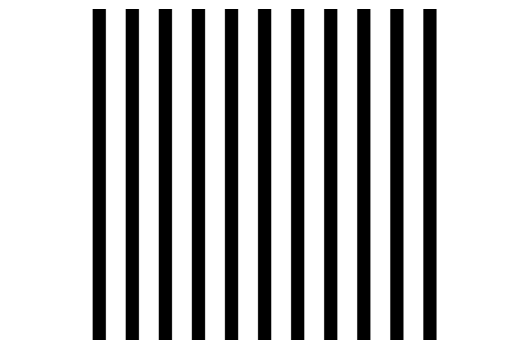

In [41]:
# Create a white 200 x 300 image
barcode = np.ones((200, 300), dtype=np.uint8) * 255

# Draw black vertical barcode lines
for x in range(50, 251, 20):
    barcode[:, x:x+8] = 0

# Show the barcode
plt.imshow(barcode, cmap="gray")
plt.axis("off");

In [42]:
# Image size
height, width = barcode.shape

# Shear amount
shear = 0.4

# 2x2 shear matrix
shear_matrix = np.array([
    [1, shear],
    [0, 1]
])

print("Shear Matrix:")
print(shear_matrix)

Shear Matrix:
[[1.  0.4]
 [0.  1. ]]


In [43]:
# Make extra room for the slant
new_width = int(width + abs(shear) * height)
new_height = height

print("Original size:", width, "x", height)
print("New size:", new_width, "x", new_height)

Original size: 300 x 200
New size: 380 x 200


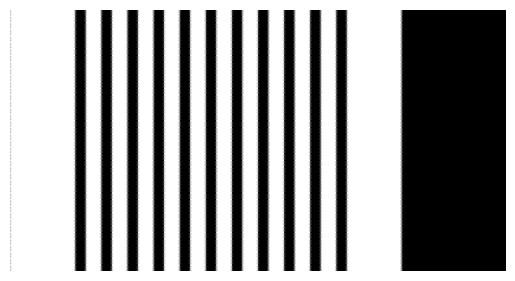

In [44]:
# Create the slanted barcode first
M = np.array([
    [1, shear, 0],
    [0, 1, 0]
], dtype=np.float32)

slanted = cv2.warpAffine(
    barcode,
    M,
    (new_width, new_height)
)

# Now straighten it
reverse_shear = -shear

M_reverse = np.array([
    [1, reverse_shear, 0],
    [0, 1, 0]
], dtype=np.float32)

straightened = cv2.warpAffine(
    slanted,
    M_reverse,
    (new_width, new_height)
)

# Show the result
plt.imshow(straightened, cmap="gray")
plt.axis("off");